# Visualize State Embeddings

In [1]:
from argparse import Namespace

import torch
from torch_geometric.loader import DataLoader

from replay_parser.parser import parse_replay_dataset

from nn.state_encoder import GNNStateEncoder

/Users/pavankantharaju/Library/Caches/pypoetry/virtualenvs/microrts-analyzer-cZshM2hG-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/pavankantharaju/Library/Caches/pypoetry/virtualenvs/microrts-analyzer-cZshM2hG-py3.11/lib/python3.11/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/Users/pavankantharaju/Library/Caches/pypoetry/virtualenvs/microrts-analyzer-cZshM2hG-py3.11/lib/python3.11/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a n

In [2]:
CONFIG = Namespace(
    seed=1,
    alpha=[0.99, 0.99],
    theta=[0.99, 0.99],
    device="cpu",
    run_name="run-0",
    ema_alpha=0.99,
    batch_size=8,
    model_name="microrts-gnn-state-encoder",
    save_model="gnn-state-model-v1.pt",
    hidden_dims=256,
    max_replays=2000,
    update_freq=100,
    project_name="microrts-graph-state-encoder",
    learning_rate=0.0004,
    read_from_zip=True,
    ignore_players=["0"],
    # input_directory="../microrts-dataset/microrts-cog-2019-standard",
    input_directory="../microrts-dataset/microrts-cog-2020-standard",
    lr_warmup_steps=1000,
    mixed_precision=None,
    allow_coordinate=False,
    max_scale_factor= 1.2,
    min_scale_factor=0.8,
    num_train_epochs=10,
    max_replay_length=64,
    state_representation='graph',
    lr_exp_schedule_gamma=0.99,
    unit_actions_to_ignore=[],
    grad_accumulation_steps=4,
    frame_skip_freq=5
    )

CONFIG.rng = torch.Generator(CONFIG.device).manual_seed(CONFIG.seed)

### Construct Dataset

In [3]:
class BatchSampler(torch.utils.data.Sampler[list[int]]):
    """
    Custom batch sampler where each "batch" is the sequence of states
    from a single replay
    """
    def __init__(self, indices: list[int]):
        self.indices = indices

    def __len__(self) -> int:
        return len(self.indices)
    
    def __iter__(self):
        for idx in self.indices:
            yield idx
        # for i in range(len(self.indices)):
        #     yield self.indices[i]

def prepare_dataloader(config: Namespace):
    """
    Prepare dataloader

    :param config: Script config
    :returns Dataloader for state dataset, node dimensions, and edge dimensions
    """

    replay_data = parse_replay_dataset(config)

    node_dims = -1
    edge_dims = -1

    dataset = []
    dataset_indices = [] # List of list of indices
    state_index = 0

    for filename, pid, trace in replay_data:
        _, players, *_ = filename.split('.')
        player_1, _, player_2, *_ = players.split('-')
        players = [player_1, player_2]
        if players[pid] in config.ignore_players:
            # Don't add player data to dataset
            # print(filename, players, players[pid])
            continue

        trace_indices = []
        for state, _ in trace:

            if node_dims == -1:
                node_dims = state.x.shape[-1]

            if edge_dims == -1:
                edge_dims = state.edge_attr.shape[-1]

            dataset.append(state)
            trace_indices.append(state_index)
            state_index += 1
        dataset_indices.append(trace_indices)

    batch_sampler = BatchSampler(dataset_indices)
    return DataLoader(dataset, generator=config.rng, shuffle=False, batch_sampler=batch_sampler), \
        replay_data

In [4]:
dataloader, cog_replay_data = prepare_dataloader(CONFIG)

100%|██████████| 2000/2000 [05:08<00:00,  6.47it/s]


## Load Model

In [5]:
# Load model to evaluate

# CONFIG.save_model = "gnn-state-model-v1.pt"
model_dict = torch.load(CONFIG.save_model)
ENCODER = GNNStateEncoder(10, 2, CONFIG.hidden_dims)
ENCODER.load_state_dict(model_dict)

# CONFIG.save_model = "gnn-replay-model-v4.pt"
# model_dict = torch.load(CONFIG.save_model)
# ENCODER = GNNReplayEncoder(10, 2, CONFIG.hidden_dims)
# ENCODER.load_state_dict(model_dict)

<All keys matched successfully>

In [7]:
graph_embeddings = None

game_segment_labels = []
map_labels = []
player_name_labels = []

# map_id_to_name = {
#     'map0': 'basesWorkers8x8A',
#     'map1': 'basesWorkers16x16A',
#     'map2': 'BWDistantResources32x32',
#     'map3': 'BroodWar/(4)BloodBath.scmB',
#     'map4': 'FourBasesWorkers8x8',
#     'map5': 'TwoBasesBarracks16x16',
#     'map6': 'NoWhereToRun9x8',
#     'map7': 'DoubleGame24x24'
#     }

map_id_to_name = {
    'map0': 'basesWorkers8x8A',
    'map1': 'basesWorkers16x16A',
    'map2': 'BWDistantResources32x32',
    'map3': 'BroodWar/(4)BloodBath.scmB',
    'map4': 'FourBasesWorkers8x8',
    'map5': 'TwoBasesBarracks16x16',
    'map6': 'NoWhereToRun9x8',
    'map7': 'DoubleGame24x24',
    'map8': 'chambers32x32v2',
    'map9': 'armyGeneration16x16',
    'map10': 'caldera16x16',
    'map11': 'paths32x32.xml'
    }

# pid_to_name = {
#     '0': 'RandomBiasedAI',
#     '1': 'POWorkerRush',
#     '2': 'POLightRush',
#     '3': 'NaiveMCTS',
#     '4': 'Tiamat',
#     '5': 'Droplet',
#     '6': 'Izanagi',
#     '7': 'MixedBot',
#     '8': 'Hybrid_HTN_MCTS_Planner_Bot',
#     '9': 'IDVRV_Bot',
#     '10': 'CompetitionSarsaSearch',
#     '11': 'UTS_Imass_SocketAI'
#     }

pid_to_name = {
    '0': 'RandomBiasedAI',
    '1': 'POWorkerRush',
    '2': 'POLightRush',
    '3': 'NaiveMCTS',
    '4': 'CoacAI',
    '5': 'UMSBot',
    '6': 'GuidedRojoA3N',
    '7': 'Rojo',
    '8': 'MentalSeal',
    '9': 'UTS_Imass_SocketAI'
    }

for inst_idx, batch in enumerate(dataloader):
    filename, pid, trace = cog_replay_data[inst_idx]

    _, players, _, map_id = filename.split('.')
    player_1, _, player_2, *_ = players.split('-')
    players = [player_1, player_2]

    if players[pid] in CONFIG.ignore_players:
        # Don't add player data to dataset
        # print(filename, players, players[pid])
        continue

    _, _, map_id = map_id.split('-')

    player_name = pid_to_name[players[pid]]
    map_name = map_id_to_name[map_id]

    # player_name_labels.append(player_name)
    # map_labels.append(map_name)

    with torch.no_grad():
        state = batch
        # _, replay_embedding, _ = ENCODER.state_encoder(
        #     state.x,
        #     state.edge_index,
        #     state.edge_attr,
        #     state.batch)

        _, replay_embedding, _ = ENCODER(
            state.x,
            state.edge_index,
            state.edge_attr,
            state.batch)

        # graph_embedding_1 = graph_embedding_1.unsqueeze(0)
        # graph_embedding = GNN_STATE_ENCODER.replay_encoder(graph_embedding_1)

        # replay_embedding = replay_embedding.squeeze(0)
        # replay_embedding = torch.mean(replay_embedding, dim=0).unsqueeze(0)

        segment_length = replay_embedding.shape[0] // 3
        # print(f"Segment length for replay with {replay_embedding.shape[0]} states: {segment_length}")
        for j in range(replay_embedding.shape[0]):
            player_name_labels.append(player_name)
            map_labels.append(map_name)
            if j < segment_length:
                # print(f"Early game: {j}")
                game_segment_labels.append('early-game')
            elif 2*segment_length > j >= segment_length:
                # print(f"Mid game: {j}")
                game_segment_labels.append('mid-game')
            else:
                # print(f"Late game: {j}")
                game_segment_labels.append('late-game')

        graph_embeddings = replay_embedding if graph_embeddings is None \
            else torch.concatenate([graph_embeddings, replay_embedding], dim=0)

graph_embeddings = graph_embeddings.numpy()

In [8]:
print(f"Number of states: {graph_embeddings.shape[0]}")

Number of states: 41234


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(font_scale=2.5)
plt.set_cmap('tab20')

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

import pandas as pd
# import numpy as np

from sklearn_extra.cluster import KMedoids

<Figure size 640x480 with 0 Axes>

## Find optimal number of clusters based on elbow method

In [10]:
from sklearn.metrics import silhouette_score

for n_clusters in range(3, 20):
    kmedoids_obj = KMedoids(n_clusters=n_clusters)
    kmedoids_obj.fit(graph_embeddings)

    score = silhouette_score(graph_embeddings, kmedoids_obj.labels_)
    print(f"Silhouette Score for {n_clusters} clusters: {score}")


Silhouette Score for 3 clusters: 0.41594892740249634
Silhouette Score for 4 clusters: 0.3365812301635742
Silhouette Score for 5 clusters: 0.2627052962779999
Silhouette Score for 6 clusters: 0.2732883393764496
Silhouette Score for 7 clusters: 0.32712358236312866
Silhouette Score for 8 clusters: 0.3761841356754303
Silhouette Score for 9 clusters: 0.37593868374824524
Silhouette Score for 10 clusters: 0.3719145357608795
Silhouette Score for 11 clusters: 0.3573216497898102
Silhouette Score for 12 clusters: 0.34436920285224915
Silhouette Score for 13 clusters: 0.3242427408695221
Silhouette Score for 14 clusters: 0.33086854219436646
Silhouette Score for 15 clusters: 0.3117964267730713
Silhouette Score for 16 clusters: 0.2984948456287384
Silhouette Score for 17 clusters: 0.373765230178833
Silhouette Score for 18 clusters: 0.36530354619026184
Silhouette Score for 19 clusters: 0.3662544786930084


In [11]:
kmedoids_obj = KMedoids(n_clusters=8)
kmedoids_obj.fit(graph_embeddings)

KMedoids()

## Plot graph embeddings

/var/folders/8p/l0sfh_s15_s_5rk6np4yvwn00000gn/T/ipykernel_14312/2239290824.py:22: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(label_df.dim1, label_df.dim2, label=str(label), c=color_map(i))


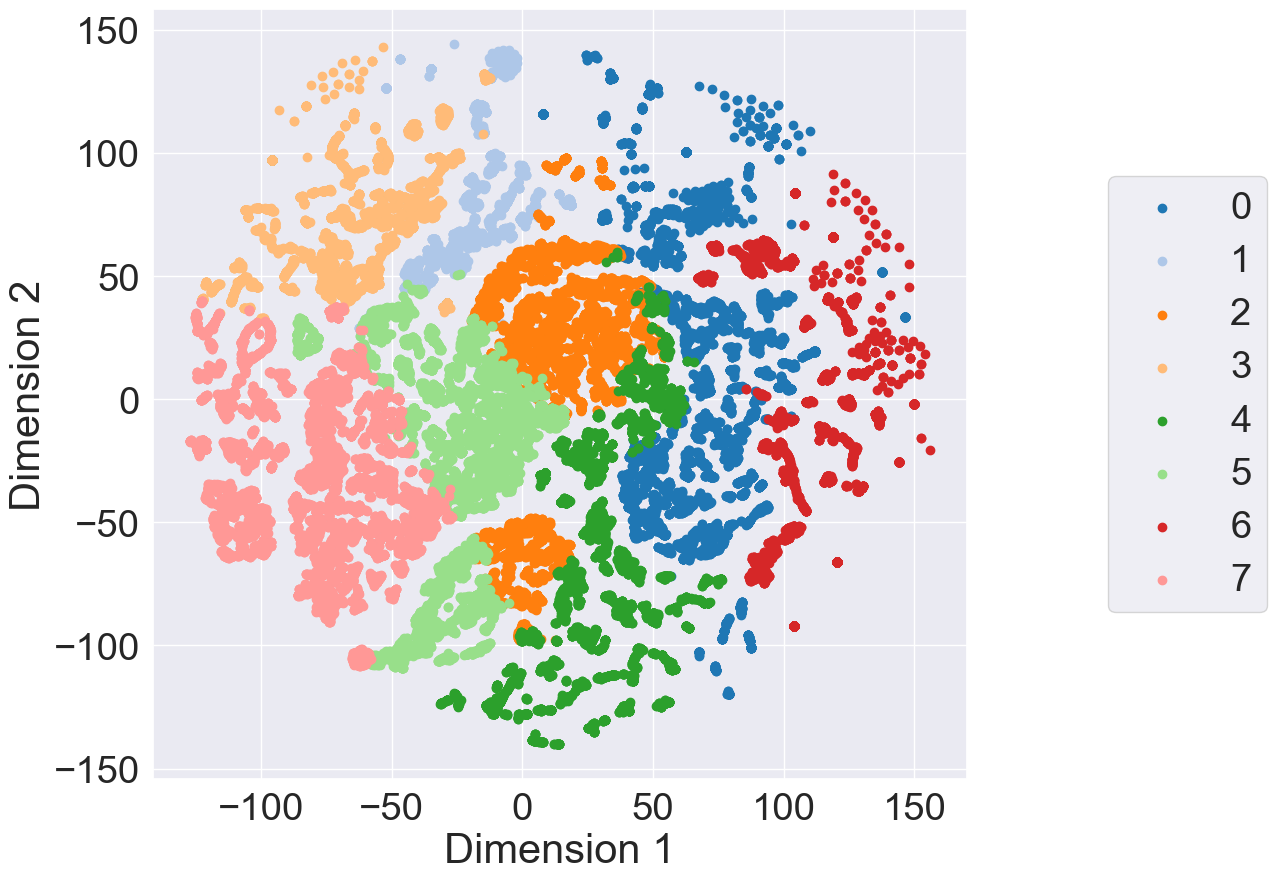

In [12]:
color_map = plt.get_cmap('tab20')

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111)
# ax = fig.add_subplot(111, projection='3d')

# dim_red_obj = UMAP(n_components=2, random_state=CONFIG.seed)
dim_red_obj = TSNE(n_components=2, random_state=CONFIG.seed)
dim_red_embedding = dim_red_obj.fit_transform(graph_embeddings)

df = pd.DataFrame(dim_red_embedding, columns=['dim1', 'dim2'])
df['game_segment_label'] = game_segment_labels
df['map_label'] = map_labels
df['kmedoids_label'] = kmedoids_obj.labels_
df['player_name'] = player_name_labels

labels = df['kmedoids_label'].values
# labels = [label for label in labels if 'mid-game' not in label]
num_labels = len(set(labels))
for i, label in enumerate(set(labels)):
    label_df = df[df.kmedoids_label == label]
    ax.scatter(label_df.dim1, label_df.dim2, label=str(label), c=color_map(i))

ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
# ax.set_zlabel("Dimension 3")
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.7, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1.15, 0.5))
# plt.close(fig)

## Valley of Old Code

In [ ]:
# from sklearn.metrics.pairwise import cosine_similarity

# sim = cosine_similarity(graph_embeddings, graph_embeddings)
# flattened_sim = sim.reshape(-1)

# plt.hist(flattened_sim, bins=10, range=(-1, 1))
# plt.show()